# GNN Training

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from gnn_project.config import Config
from gnn_project.training.train_utils import train_or_load_model, load_data

## GNN Model

In [ ]:
config = Config(
    ml_data_dir='/Users/hoda_hamdy/Documents/Projects/fleetpy/FleetPy/gnn_project/data',
    experiment_name='gnn_v1',
    sim_start=0,
    sim_end=2*60*60,
    load_saved_model=True,
    overwrite_data=False,
    recompute_norm_stats=False,
    log_level='DEBUG',
)

In [3]:
import logging
logging.basicConfig(level=config.log_level)

In [4]:
data, masks = load_data(config)

DEBUG:gnn_project.dataloaders.gnn_dataloader:Total number of scenarios: 3
DEBUG:gnn_project.dataloaders.gnn_dataloader:Train size: 1, Val size: 1, Test size: 1
Normalizing scenarios: 100%|██████████| 3/3 [00:02<00:00,  1.25it/s]
DEBUG:gnn_project.dataloaders.gnn_dataloader:Scenario split: Train=1, Val=1, Test=1 scenarios
DEBUG:gnn_project.dataloaders.gnn_dataloader:Timestep split: Train=240, Val=238, Test=240 timesteps
DEBUG:gnn_project.dataloaders.gnn_dataloader:Saved feature names to /Users/hoda_hamdy/Documents/Projects/fleetpy/FleetPy/gnn_project/data/processed/gnn_v1/feature_names.json


## Feature Names
Access feature names for analysis

In [5]:
from gnn_project.training.train_utils import load_feature_names

# Load feature names for the current experiment
feature_names = load_feature_names(config)

# Display feature names for each node/edge type
for key, names in feature_names.items():
    print(f"\n{key}: {len(names)} features")
    print(names[:5] if len(names) > 5 else names)  # Show first 5 features

DEBUG:gnn_project.dataloaders.gnn_dataloader:Loaded feature names from /Users/hoda_hamdy/Documents/Projects/fleetpy/FleetPy/gnn_project/data/processed/gnn_v1/feature_names.json



request: 42 features
['clustering_coeff', 'd_lat', 'd_lon', 'demand_supply_ratio', 'direct_td']

vehicle: 21 features
['clustering_coeff', 'in_degree', 'in_degree_from_requests', 'lat', 'lon']

vehicle__connects__request: 46 features
['arrival_slack', 'assigned_max_pooling_score', 'assigned_mean_pooling_score', 'assigned_min_max_detour_ratio', 'assigned_overlap_count']

request__connects__request: 71 features
['avg_detour_distance', 'avg_detour_ratio', 'avg_shared_ride_time', 'avg_time_detour', 'avg_time_detour_ratio']


In [6]:
model, trainer = train_or_load_model(config, data, masks)

INFO:gnn_project.training.train_utils:Loading model from /Users/hoda_hamdy/Documents/Projects/fleetpy/FleetPy/gnn_project/data/models/gnn_v1/best_model.pt


## Visualization

In [7]:
logging.basicConfig(level='INFO')

In [8]:
from gnn_project.analysis.plots import visualize_graph
from gnn_project.training.train_utils import get_edge_predictions
from gnn_project.defaults import *

scenario = 0  # Scenario index for the selected graph
scenario_sizes = [240, 238, 240]  # Example scenario sizes
scenario_start_idx = sum(scenario_sizes[:scenario])


DEBUG:matplotlib:matplotlib data path: /Users/hoda_hamdy/Documents/Tools/Anaconda/envs/FleetPy/lib/python3.10/site-packages/matplotlib/mpl-data
DEBUG:matplotlib:CONFIGDIR=/Users/hoda_hamdy/.matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is darwin
DEBUG:matplotlib:CACHEDIR=/Users/hoda_hamdy/.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/hoda_hamdy/.matplotlib/fontlist-v390.json


Edge from v69 to r0: score=0.65, is_true=True, type=VR
Edge from v43 to r0: score=0.53, is_true=False, type=VR
Edge from v59 to r0: score=0.22, is_true=False, type=VR
Edge from v42 to r0: score=0.21, is_true=False, type=VR
Edge from v24 to r0: score=0.21, is_true=False, type=VR
Edge from v97 to r1: score=0.48, is_true=False, type=VR
Edge from v119 to r1: score=0.32, is_true=True, type=VR
Edge from v33 to r1: score=0.23, is_true=False, type=VR
Edge from v76 to r1: score=0.16, is_true=False, type=VR
Edge from v4 to r1: score=0.13, is_true=False, type=VR


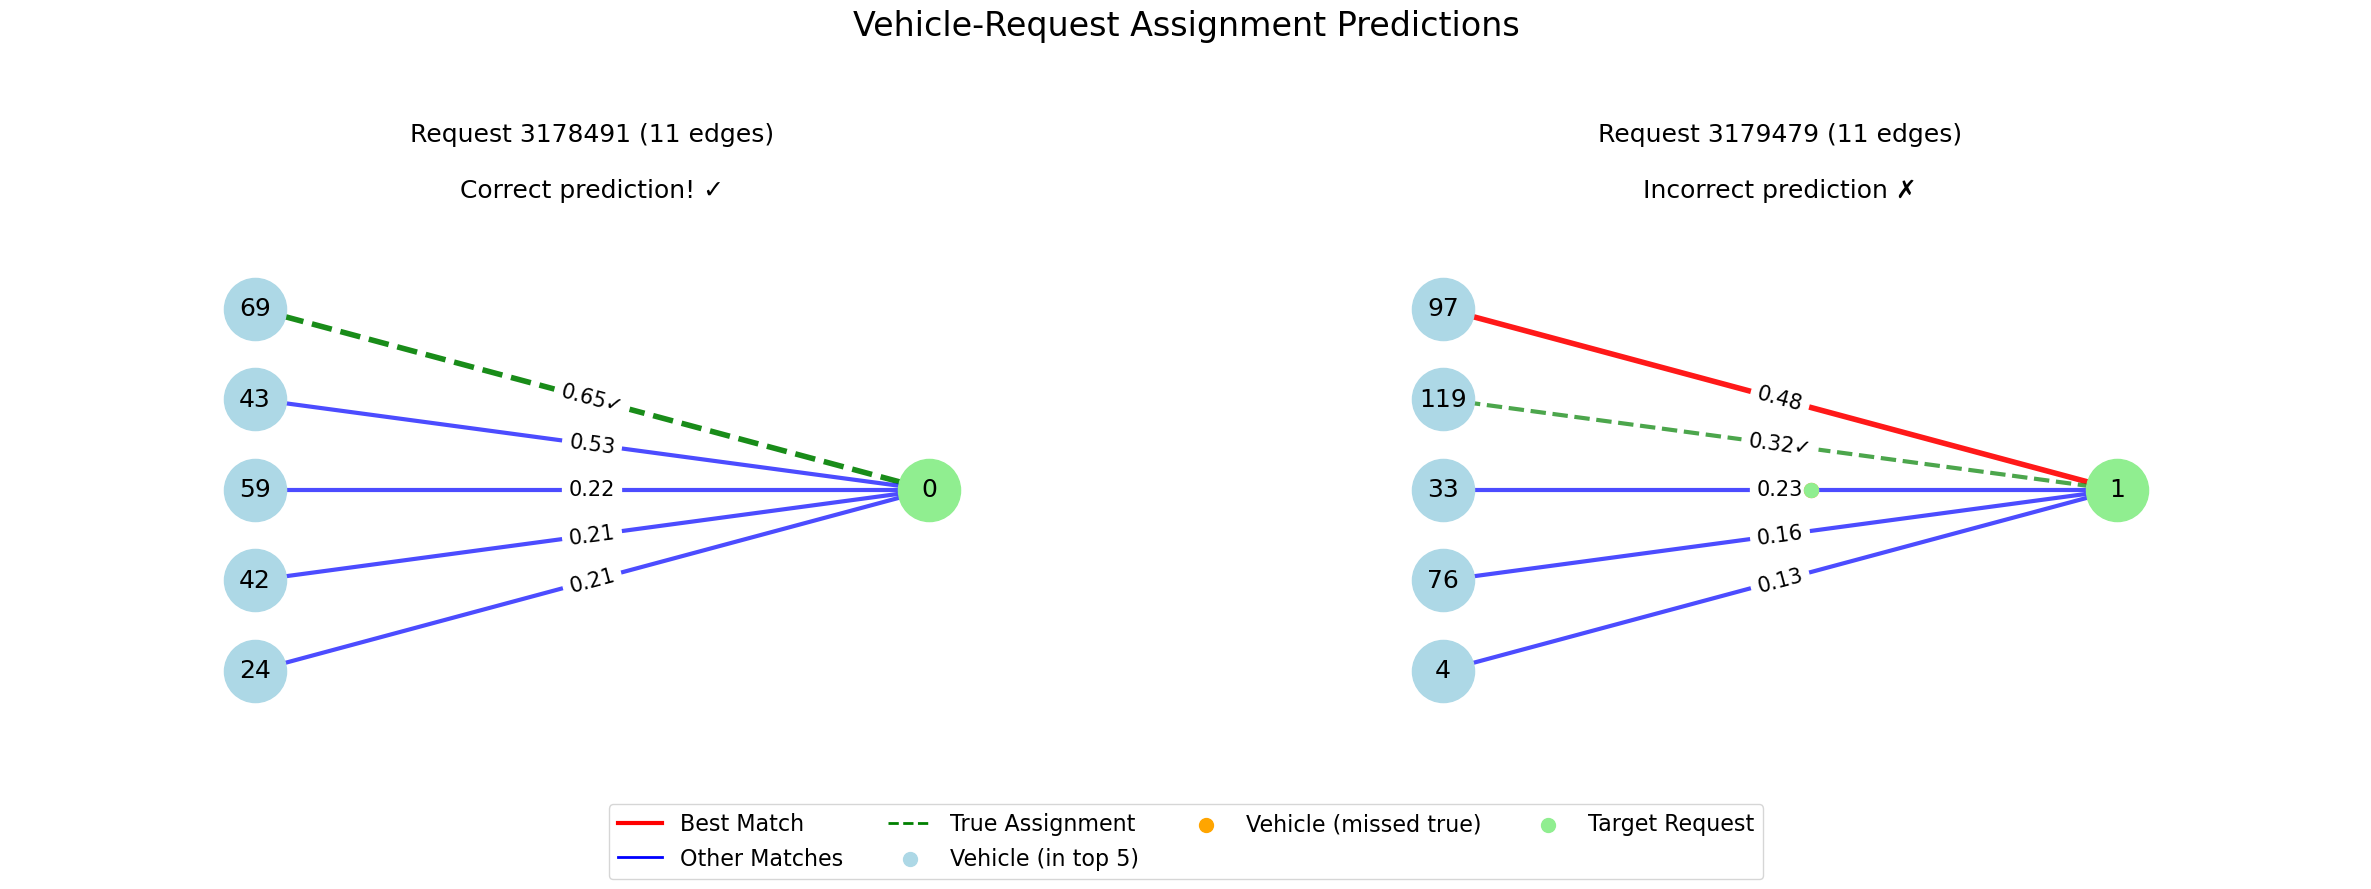

In [12]:
graph_idx = 12 # Index of the graph to visualize
predictions = get_edge_predictions(data[graph_idx], model, device='cpu')
edge_types = [VR_EDGE_NAME]
visualize_graph(data, graph_idx=graph_idx, predictions=predictions, edge_types=edge_types, scenario_start_idx=scenario_start_idx);

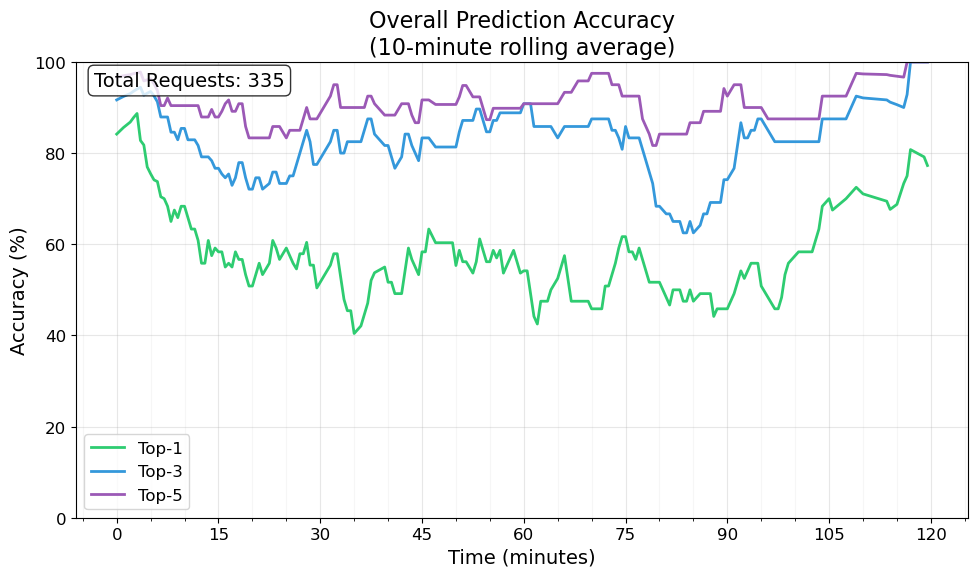

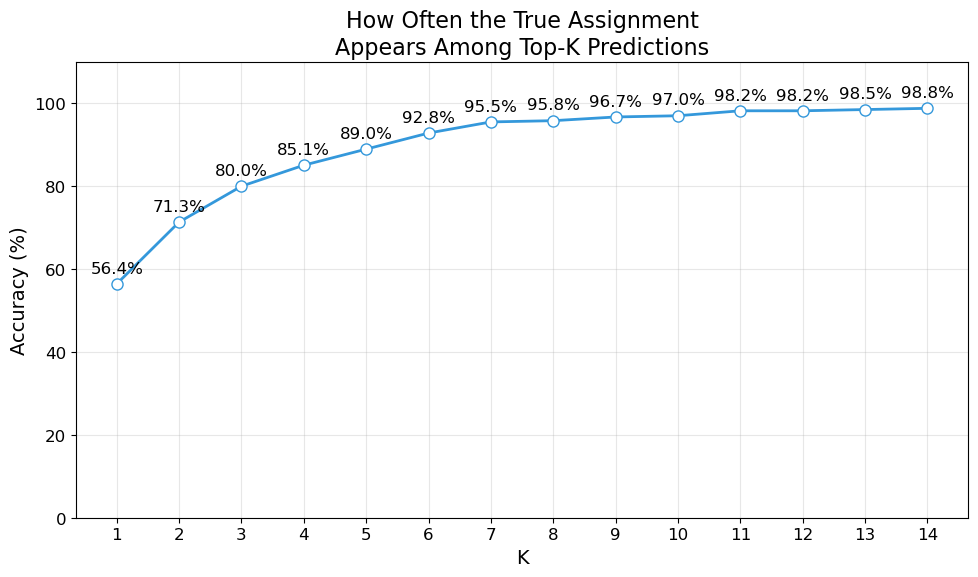

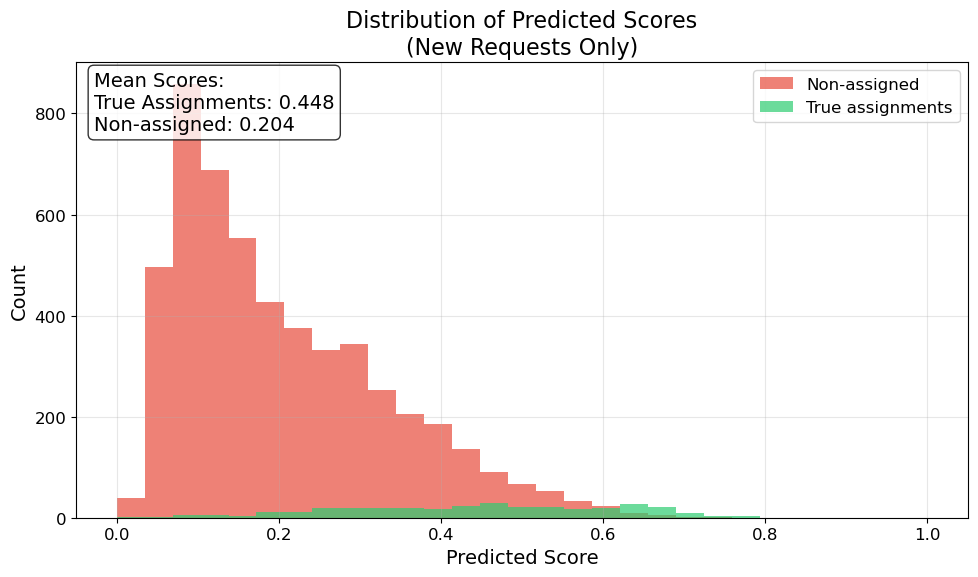

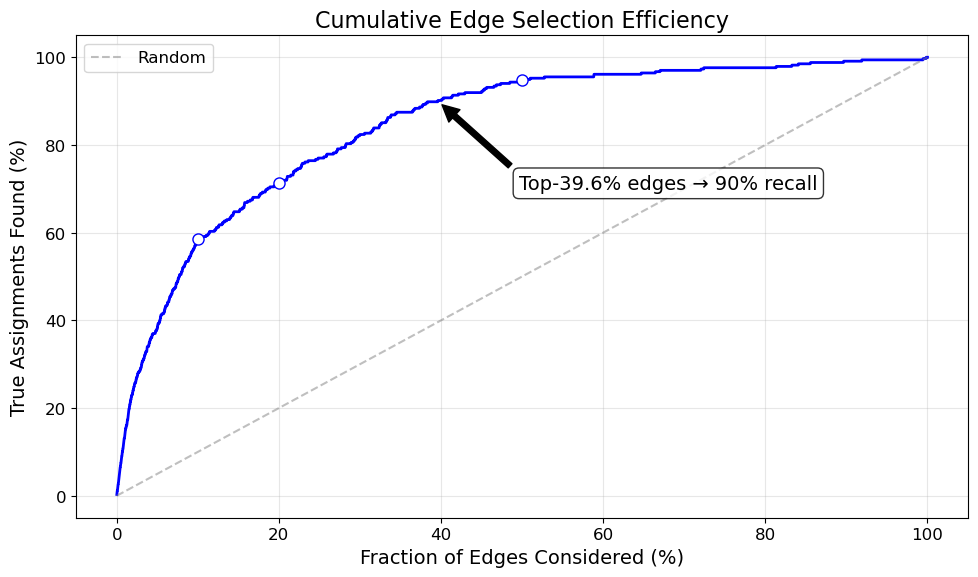

In [14]:
# Analyze model performance over a range of graphs
from gnn_project.analysis.plots import analyze_model_performance
import matplotlib.pyplot as plt
from gnn_project.defaults import *
num_graphs = masks[TEST_MASKS].sum().item()
start_idx = len(data) - num_graphs  # Starting graph index

edge_types = [VR_EDGE_NAME]
predictions = [get_edge_predictions(data[i], model, device=config.device) for i in range(start_idx, start_idx + num_graphs)]
fig = analyze_model_performance(data, start_idx, num_graphs, predictions, edge_types=edge_types)

In [15]:
for i, graph in enumerate(data):
    edge_type = VR_EDGE_NAME
    # find an true assignment edge and print the graph index to ease visualization
    if graph[edge_type].y.sum().item() > 0:
        print(f"Graph {i} has true assignments.")
        # print the edges with true assignments
        edge_indices = graph[edge_type].edge_index[:, graph[edge_type].y == 1]
        print(f"True assignment edges (source -> target):")
        for src, tgt in edge_indices.t().tolist():
            print(f"{src} -> {tgt}")
        break  # Stop after finding the first graph with true assignments

Graph 0 has true assignments.
True assignment edges (source -> target):
11 -> 0
